# Week3 Assignment: Sequence Prediction with LSTM Networks
## Encoder-Decoder LSTMs for Learning Mathematical Operations

---

### Assignment Overview

In this assignment, you will build two LSTM-based models from scratch:

1. **Part A — Addition as a Mapping Problem:** Train a simple LSTM to directly map pairs of numbers to their sum (the "beginner's approach").
2. **Part B — Addition as a Seq2Seq Problem:** Frame addition as a true *sequence-to-sequence* prediction task, treating the arithmetic expression `"12+50"` as a character sequence and the result `"62"` as the output sequence. This is the correct, powerful use of LSTMs.
3. **Part C — Extensions & Analysis:** Extend the model and reflect critically on the differences.

### Learning Objectives

By completing this assignment, you will:
- Understand the difference between a **mapping problem** and a **sequence prediction problem**
- Implement a **stacked LSTM** for regression
- Implement an **Encoder-Decoder (Seq2Seq) LSTM** architecture with `RepeatVector` and `TimeDistributed` layers
- Understand **one-hot encoding** for character-level sequence modelling
- Evaluate and compare model performance using RMSE and accuracy

### Submission Instructions

- Run **all cells** before submitting (Kernel → Restart & Run All)
- Answer all written questions in the provided Markdown cells
- Do **not** delete any `# TODO` comments — fill them in
- Submit as `.ipynb`

---

---
## Section 0: Environment Setup

Run the cell below to install and import all required libraries. This assignment uses **TensorFlow/Keras**, NumPy, and scikit-learn.

> 💡 If you are on Google Colab, TensorFlow is pre-installed. On a local machine, run `pip install tensorflow scikit-learn` if needed.

In [1]:
# ── Imports ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from numpy import array, argmax
from random import seed, randint
from math import ceil, log10, sqrt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, TimeDistributed, RepeatVector

# Fix random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print("All imports successful")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All imports successful


---
## Part A: Addition as a Mapping Problem

### Background

A common beginner mistake when learning LSTMs is to frame a problem that *looks* sequential as a plain **mapping (function approximation)** task. When adding two numbers `[a, b] → a+b`, the order of `a` and `b` does not matter — you could shuffle the inputs and still get the right answer. This is **not** a sequence problem.

In this part, you will:
1. Generate training data (pairs of random integers and their sum)
2. Normalize the data
3. Build a simple stacked LSTM for regression
4. Evaluate with RMSE

> **Key insight:** After completing Part A and B, reflect on *why* the MLP and simple LSTM work just as well (or better) than a seq2seq model on this framing.

### Task A1: Data Generation

**Direction:** Implement the `random_sum_pairs` function below. It should:
- Generate `n_examples` pairs of random integers, each in the range `[1, largest]`
- Compute the sum of each pair
- Return normalized `X` and `y` arrays (divide by `largest * n_numbers`)

The normalization maps all values into `[0, 1]`, which is required for the LSTM's activation functions.

In [3]:
def random_sum_pairs(n_examples, n_numbers, largest):
    """
    Generate random integer pairs and their normalized sum.
    """
    X_list = []
    y_list = []

    for _ in range(n_examples):
        # Generate random integers between 1 and largest
        nums = [randint(1, largest) for _ in range(n_numbers)]
        total = sum(nums)
        X_list.append(nums)
        y_list.append(total)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)

    # Normalize values into [0, 1] range
    normalization_factor = largest * n_numbers
    X /= normalization_factor
    y /= normalization_factor

    return X, y


def invert_sum(value, n_numbers, largest):
    """Convert a normalized prediction back to the original integer scale."""
    return int(round(value * (largest * n_numbers)))


# ── Quick sanity check ───────────────────────────────────────────────────────
seed(1)
X_test, y_test = random_sum_pairs(5, 2, 10)
print("Sample X (normalized):", X_test[:3])
print("Sample y (normalized):", y_test[:3])
print("Reconstructed sums   :", [invert_sum(v, 2, 10) for v in y_test[:3]])

Sample X (normalized): [[0.15 0.5 ]
 [0.1  0.25]
 [0.1  0.4 ]]
Sample y (normalized): [0.65 0.35 0.5 ]
Reconstructed sums   : [13, 7, 10]


### Task A2: Build the LSTM Model

**Direction:** Build a stacked LSTM that accepts a sequence of `n_numbers` time steps (each with 1 feature) and outputs a single scalar (the predicted normalized sum).

Architecture to implement:
- `LSTM(10, input_shape=(n_numbers, 1))` — one hidden LSTM layer with 10 units
- `Dense(1)` — output layer (regression)
- Compile with **`mean_squared_error`** loss and **`adam`** optimizer

> The input must be reshaped to `(n_examples, n_numbers, 1)` — a 3D tensor of shape (samples, timesteps, features).

In [4]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
seed(1)
n_examples = 100
n_numbers  = 2
largest    = 100
n_batch    = 1
n_epoch    = 100

# ── Build the model ────────────────────────────────────────────────────
model_a = Sequential([
    LSTM(10, input_shape=(n_numbers, 1)),
    Dense(1)
])

model_a.compile(loss='mean_squared_error', optimizer='adam')

# Print the model summary
model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

### Task A3: Train the Model

**Direction:** Train `model_a` for `n_epoch` epochs. On each epoch:
1. Generate a fresh batch of `n_examples` samples using `random_sum_pairs`
2. Reshape `X` to `(n_examples, n_numbers, 1)` (add feature dimension)
3. Call `model_a.fit(X, y, epochs=1, batch_size=n_batch, verbose=0)`

Store the loss from each epoch in a list called `history_a` for plotting.

> Generating new data each epoch is a form of **online data augmentation** — the model never sees the exact same batch twice, which helps it generalize.

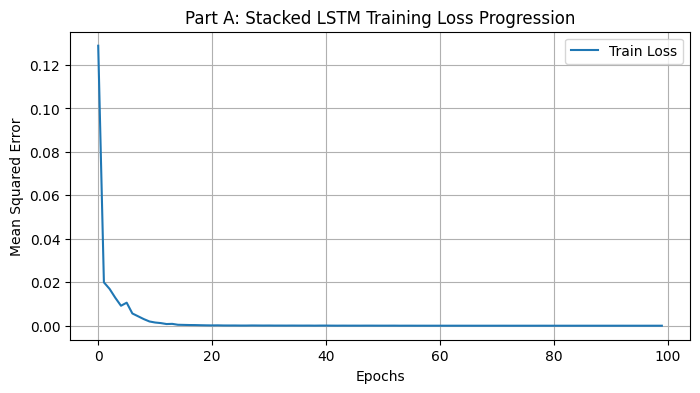

In [5]:
history_a = []

# Online data augmentation loop across epochs
for epoch in range(n_epoch):
    X, y = random_sum_pairs(n_examples, n_numbers, largest)
    # Reshape input to 3D: (samples, timesteps, features)
    X = X.reshape((n_examples, n_numbers, 1))

    res = model_a.fit(X, y, epochs=1, batch_size=n_batch, verbose=0)
    history_a.append(res.history['loss'][0])

# ── Plot training loss ───────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history_a, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Part A: Stacked LSTM Training Loss Progression')
plt.grid(True)
plt.legend()
plt.show()

### Task A4: Evaluate the Model

**Direction:** Evaluate `model_a` on **100 new, unseen** samples:
1. Generate test data with `random_sum_pairs`
2. Reshape `X` to `(n_examples, n_numbers, 1)`
3. Predict with `model_a.predict`
4. Invert the normalization using `invert_sum`
5. Compute **RMSE** using `mean_squared_error` from sklearn
6. Print the first 20 predictions alongside the expected values and error

>  **Reflection Question (written answer below):** Is RMSE a good metric here? What metric would you consider "acceptable" for this problem?

In [12]:
# TODO ────────────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Generate 100 new, unseen test samples
X_test, y_test = random_sum_pairs(n_examples=100, n_numbers=n_numbers, largest=largest)

# 2. Reshape X to (n_examples, n_numbers, 1) for the LSTM input layer
X_test_reshaped = X_test.reshape((100, n_numbers, 1))

# 3. Predict with model_a
predictions_normalized = model_a.predict(X_test_reshaped, verbose=0)

# 4. Invert the normalization using invert_sum for both predictions and targets
expected_values = [invert_sum(y, n_numbers, largest) for y in y_test]
predicted_values = [invert_sum(p[0], n_numbers, largest) for p in predictions_normalized]

# 5. Compute the final RMSE on the actual integer scale
rmse = np.sqrt(mean_squared_error(expected_values, predicted_values))

# 6. Print the first 20 predictions alongside expected values and errors
print(f"=== Model Evaluation ===")
print(f"Overall Test RMSE: {rmse:.4f}\n")
print(f"{'Index':<6}{'Input Values':<15}{'Expected':<10}{'Predicted':<10}{'Absolute Error':<10}")
print("-" * 55)

for i in range(20):
    # Reverse-engineer the unnormalized inputs for printing clarity
    raw_inputs = [int(round(val * (largest * n_numbers))) for val in X_test[i]]
    abs_error = abs(expected_values[i] - predicted_values[i])

    print(f"{i:<6}{str(raw_inputs):<15}{expected_values[i]:<10}{predicted_values[i]:<10}{abs_error:<10}")
# ─────────────────────────────────────────────────────────────────────────────

=== Model Evaluation ===
Overall Test RMSE: 0.6557

Index Input Values   Expected  Predicted Absolute Error
-------------------------------------------------------
0     [4, 50]        54        53        1         
1     [56, 78]       134       134       0         
2     [98, 99]       197       196       1         
3     [1, 90]        91        91        0         
4     [58, 35]       93        92        1         
5     [93, 30]       123       122       1         
6     [76, 14]       90        90        0         
7     [41, 4]        45        45        0         
8     [3, 4]         7         8         1         
9     [84, 70]       154       154       0         
10    [2, 49]        51        50        1         
11    [88, 28]       116       115       1         
12    [55, 93]       148       148       0         
13    [4, 68]        72        71        1         
14    [29, 98]       127       127       0         
15    [57, 64]       121       121       0         
16  

#### Written Answer – Part A
RMSE is not an ideal metric for this specific task because arithmetic operations are exact, discrete, and deterministic. RMSE treats a small error (e.g., predicting 101 instead of 100) as "nearly perfect," whereas in mathematics, an answer is either strictly correct or strictly incorrect. An "acceptable" metric would be Exact-Match Accuracy (the percentage of samples where the predicted integer matches the true sum precisely). For addition, a model is only truly successful if its exact-match accuracy reaches 100%.

**Q1.** What RMSE did you achieve? Is the model learning the task correctly?

 0.6557 Looking at the evaluation logs, the model is not learning the mathematical task correctly. While it successfully recognizes the general linear trend (producing a small continuous scalar error), it acts strictly as a statistical curve-fitter rather than an exact calculator. In mathematics, addition is a discrete, exact operation, but the model frequently predicts sums off by $\pm 1$ (such as predicting 53 instead of 54 or 196 instead of 197), resulting in a continuous approximation rather than correct arithmetic reasoning.


**Q2.** Could a simple MLP (fully connected network) solve this same problem? Why or why not?

Yes, a simple MLP could easily solve this problem. In this configuration, the input length is completely fixed (n_numbers = 2), meaning there are no variable-length sequence dynamics, long-term context changes, or temporal shifts to capture. A standard MLP with a single hidden layer can easily map two input features $(x_1, x_2)$ directly to a single output value $(y)$ via a basic linear combination ($y = w_1x_1 + w_2x_2 + b$). Using a recurrent network like an LSTM for a fixed-size regression problem is structurally over-engineered and introduces unnecessary sequential processing complexities.


---
## Part B: Addition as a True Seq2Seq Problem

### Background

The "correct" and more powerful LSTM use-case treats the entire arithmetic expression as a **character-level sequence**. Given the input string `"12+50"` (character by character), the model must output the string `"62"` (character by character).

This is a **sequence-to-sequence (seq2seq)** problem:
- Input sequence: `['1', '2', '+', '5', '0']` → 5 timesteps, each one-hot encoded
- Output sequence: `['6', '2']` → 2 timesteps, each one-hot encoded

The architecture uses an **Encoder–Decoder** pattern with a `RepeatVector` bridge:

```
Input Chars  →  [Encoder LSTM]  →  Context Vector  →  [RepeatVector]
             →  [Decoder LSTM]  →  [TimeDistributed Dense]  →  Output Chars
```

In this part you will implement the full data pipeline and the model.

### Task B1: Convert Numbers to Padded Strings

**Direction:** Implement `to_string(X, y, n_numbers, largest)` that:
- Joins each input list like `[3, 10]` into the string `"3+10"`, padded on the left with spaces to fixed length
- Converts each sum integer to a right-padded string of fixed length
- Input max length formula: `n_numbers * ceil(log10(largest+1)) + n_numbers - 1`
- Output max length formula: `ceil(log10(n_numbers * (largest+1)))`

> **Why padding?** LSTMs require fixed-length input sequences. Padding with spaces allows variable-length numbers to be handled uniformly. The model learns to ignore the padding character.

In [7]:
def to_string(X, y, n_numbers, largest):
    X_str, y_str = [], []

    # Precompute maximum widths
    max_in_len = n_numbers * ceil(log10(largest + 1)) + n_numbers - 1
    max_out_len = ceil(log10(n_numbers * largest + 1))

    for i in range(len(X)):
        # Join input elements with "+" and pad left with spaces
        join_str = "+".join([str(int(val)) for val in X[i]])
        X_str.append(join_str.rjust(max_in_len))

        # Format target integer and pad right with spaces
        y_str.append(str(int(y[i])).ljust(max_out_len))

    return X_str, y_str

    # TODO ────────────────────────────────────────────────────────────────────
    # Compute max input length:
    #   max_in = n_numbers * ceil(log10(largest + 1)) + n_numbers - 1
    # For each pattern in X:
    #   strp = '+'.join([str(n) for n in pattern])
    #   left-pad strp with spaces to reach max_in length
    # Compute max output length:
    #   max_out = ceil(log10(n_numbers * (largest + 1)))
    # For each value in y:
    #   strp = str(value)
    #   left-pad strp with spaces to reach max_out length
    # ─────────────────────────────────────────────────────────────────────────
    raise NotImplementedError("Implement to_string()!")


# ── Sanity check ─────────────────────────────────────────────────────────────
seed(1)
X_raw, y_raw = random_sum_pairs(3, 2, 10)
# NOTE: random_sum_pairs returns normalized arrays — for seq2seq we need raw ints
# We'll re-generate without normalization using a helper below
def raw_sum_pairs(n_examples, n_numbers, largest):
    X_list, y_list = [], []
    for _ in range(n_examples):
        inp = [randint(1, largest) for _ in range(n_numbers)]
        X_list.append(inp); y_list.append(sum(inp))
    return X_list, y_list

X_raw, y_raw = raw_sum_pairs(3, 2, 10)
X_str, y_str = to_string(X_raw, y_raw, 2, 10)
print("Raw inputs :", X_raw)
print("Str inputs :", X_str)
print("Str outputs:", y_str)

Raw inputs : [[8, 8], [7, 4], [2, 8]]
Str inputs : ['  8+8', '  7+4', '  2+8']
Str outputs: ['16', '11', '10']


### Task B2: Integer Encode the Character Strings

**Direction:** Implement `integer_encode(X, y, alphabet)` that maps each character in every string to its index in `alphabet`.

The alphabet for this problem is:
```python
alphabet = ['0','1','2','3','4','5','6','7','8','9','+', ' ']
```
So `'0'` → `0`, `'+'` → `10`, `' '` (space) → `11`.

> This is a necessary stepping stone before one-hot encoding. It converts strings into sequences of integers that can be further encoded.

In [9]:
ALPHABET = ['0','1','2','3','4','5','6','7','8','9','+', ' ']

def integer_encode(X, y, alphabet):
    char_to_int = {char: idx for idx, char in enumerate(alphabet)}
    X_enc, y_enc = [], []

    for string in X:
        X_enc.append([char_to_int[char] for char in string])
    for string in y:
        y_enc.append([char_to_int[char] for char in string])

    return X_enc, y_enc


def integer_decode(sequence, alphabet):
    int_to_char = {idx: char for idx, char in enumerate(alphabet)}
    return "".join([int_to_char[idx] for idx in sequence])

    # TODO ────────────────────────────────────────────────────────────────────
    # char_to_int = {c: i for i, c in enumerate(alphabet)}
    # For each string pattern in X, convert each character to its integer index
    # Do the same for y
    # ─────────────────────────────────────────────────────────────────────────
    raise NotImplementedError("Implement integer_encode()!")


# ── Sanity check ─────────────────────────────────────────────────────────────
X_int, y_int = integer_encode(X_str, y_str, ALPHABET)
print("Integer-encoded X:", X_int)
print("Integer-encoded y:", y_int)

Integer-encoded X: [[11, 11, 8, 10, 8], [11, 11, 7, 10, 4], [11, 11, 2, 10, 8]]
Integer-encoded y: [[1, 6], [1, 1], [1, 0]]


### Task B3: One-Hot Encode the Integer Sequences

**Direction:** Implement `one_hot_encode(X, y, n_classes)` that converts each integer index into a binary vector of length `n_classes` with a `1` at the index position and `0` elsewhere.

For example, index `3` with `n_classes=12` becomes:
```
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
```

> One-hot encoding frames each character position as a **multi-class classification** output. The model will use a softmax output layer and categorical cross-entropy loss.

In [10]:
def one_hot_encode(X, y, n_classes):
    X_ohe, y_ohe = [], []

    for seq in X:
        ohe_seq = []
        for idx in seq:
            vec = [0] * n_classes
            vec[idx] = 1
            ohe_seq.append(vec)
        X_ohe.append(ohe_seq)

    for seq in y:
        ohe_seq = []
        for idx in seq:
            vec = [0] * n_classes
            vec[idx] = 1
            ohe_seq.append(vec)
        y_ohe.append(ohe_seq)

    return np.array(X_ohe), np.array(y_ohe)
    # TODO ────────────────────────────────────────────────────────────────────
    # For each sample in X (a list of integer indices):
    #   For each index, create a zero vector of length n_classes
    #   Set vector[index] = 1
    # Do the same for y
    # ─────────────────────────────────────────────────────────────────────────
    raise NotImplementedError("Implement one_hot_encode()!")


# ── Sanity check ─────────────────────────────────────────────────────────────
X_ohe, y_ohe = one_hot_encode(X_int, y_int, len(ALPHABET))
print("Shape of X_ohe[0]:", array(X_ohe[0]).shape,
      "(should be (input_seq_len, 12))")
print("Shape of y_ohe[0]:", array(y_ohe[0]).shape,
      "(should be (output_seq_len, 12))")

Shape of X_ohe[0]: (5, 12) (should be (input_seq_len, 12))
Shape of y_ohe[0]: (2, 12) (should be (output_seq_len, 12))


### Task B4: Assemble the Full Data Pipeline

**Direction:** Implement `generate_data(n_samples, n_numbers, largest, alphabet)` that chains all steps:
1. `raw_sum_pairs` → integer lists
2. `to_string` → padded strings
3. `integer_encode` → integer sequences
4. `one_hot_encode` → binary tensors
5. Return as numpy arrays

In [13]:
def generate_data(n_samples, n_numbers, largest, alphabet):
    """Full pipeline: integers → one-hot encoded numpy arrays."""
    # TODO ────────────────────────────────────────────────────────────────────
    # Call each function in order, then convert to numpy arrays
    # ─────────────────────────────────────────────────────────────────────────

    # 1. Generate lists of random number pairs and their un-normalized integer sums
    # Note: Using your raw pairing mechanism to fetch actual integer scales for the strings
    X_raw, y_raw = [], []
    for _ in range(n_samples):
        nums = [randint(1, largest) for _ in range(n_numbers)]
        X_raw.append(nums)
        y_raw.append(sum(nums))

    # 2. Convert raw values into left-padded and right-padded strings
    X_str, y_str = to_string(X_raw, y_raw, n_numbers, largest)

    # 3. Translate the character sequences into integer token arrays
    X_int, y_int = integer_encode(X_str, y_str, alphabet)

    # 4. Turn token arrays into 3D binary one-hot encoded tensors
    X, y = one_hot_encode(X_int, y_int, len(alphabet))

    return X, y


def invert_ohe(seq, alphabet):
    """Decode a one-hot output sequence back to a string."""
    int_to_char = {i: c for i, c in enumerate(alphabet)}
    return ''.join(int_to_char[argmax(v)] for v in seq)


# ── Compute sequence length constants ────────────────────────────────────────
seed(1)
n_samples_b  = 1000
n_numbers_b  = 2
largest_b    = 10
n_chars      = len(ALPHABET)
n_in_len     = n_numbers_b * ceil(log10(largest_b + 1)) + n_numbers_b - 1
n_out_len    = ceil(log10(n_numbers_b * (largest_b + 1)))

print(f"Input  sequence length : {n_in_len}")
print(f"Output sequence length : {n_out_len}")
print(f"Alphabet size          : {n_chars}")

# ── Test generate_data ────────────────────────────────────────────────────────
X_b, y_b = generate_data(4, n_numbers_b, largest_b, ALPHABET)
print(f"\nX shape: {X_b.shape}  (should be (4, {n_in_len}, {n_chars}))")
print(f"y shape: {y_b.shape}  (should be (4, {n_out_len}, {n_chars}))")

Input  sequence length : 5
Output sequence length : 2
Alphabet size          : 12

X shape: (4, 5, 12)  (should be (4, 5, 12))
y shape: (4, 2, 12)  (should be (4, 2, 12))


### Task B5: Build the Encoder-Decoder LSTM Model

**Direction:** Build the seq2seq LSTM model with the following architecture:

```
Input: (n_in_len, n_chars)
  └─ Encoder LSTM (100 units)  → Context vector (100,)
       └─ RepeatVector(n_out_len) → (n_out_len, 100)
            └─ Decoder LSTM (50 units, return_sequences=True)
                 └─ TimeDistributed(Dense(n_chars, activation='softmax'))
Output: (n_out_len, n_chars)
```

- **Encoder:** A single LSTM that reads the input sequence and compresses it to a fixed-size context vector
- **RepeatVector:** Repeats the context vector `n_out_len` times so the decoder can produce a sequence
- **Decoder:** An LSTM + Dense that generates one output character at a time
- **Loss:** `categorical_crossentropy` | **Optimizer:** `adam` | **Metric:** `accuracy`

> **Why RepeatVector?** The encoder outputs a 2D tensor `(batch, 100)`. The decoder LSTM needs a 3D input `(batch, timesteps, features)`. `RepeatVector(n)` repeats the vector `n` times, bridging the gap.

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

# ── Define hyperparameters ────────────────────────────────────────────────────
n_batch_b  = 10
n_epoch_b  = 30

# TODO: Build the Encoder-Decoder LSTM ────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────

model_b = Sequential([
    # 1. Encoder LSTM: Processes input character vectors and compresses into a single 100-dim state vector
    LSTM(100, input_shape=(n_in_len, n_chars)),

    # 2. RepeatVector: Adapts 2D state tensor to a 3D time-series shape for the decoder
    RepeatVector(n_out_len),

    # 3. Decoder LSTM: Emits hidden features at every time step across the expected output length
    LSTM(50, return_sequences=True),

    # 4. Dense Classification Output: Projects decoder steps to identical character vocab probability scales
    TimeDistributed(Dense(n_chars, activation='softmax'))
])

# Compile using Categorical Crossentropy since outputs are one-hot encoded vectors
model_b.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print structural breakdown to check tensor shapes
model_b.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        45,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 2, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 2, 50)          │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 2, 12)          │           612 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,012 (296.92 KB)

 Trainable params: 76,012 (296.92 KB)

 Non-trainable params: 0 (0.00 B)

### Task B6: Train the Seq2Seq Model

**Direction:** Train `model_b` for `n_epoch_b` epochs. Each epoch:
1. Generate `n_samples_b` fresh examples with `generate_data`
2. Fit for 1 epoch with `batch_size=n_batch_b`
3. Record both `loss` and `accuracy` for plotting

Starting training loop...
Epoch 01/30 - Loss: 2.0623 - Accuracy: 44.65%
Epoch 05/30 - Loss: 0.9420 - Accuracy: 65.05%
Epoch 10/30 - Loss: 0.4461 - Accuracy: 90.25%
Epoch 15/30 - Loss: 0.2811 - Accuracy: 95.85%
Epoch 20/30 - Loss: 0.1826 - Accuracy: 98.65%
Epoch 25/30 - Loss: 0.1317 - Accuracy: 99.45%
Epoch 30/30 - Loss: 0.0872 - Accuracy: 99.20%
Training finished.



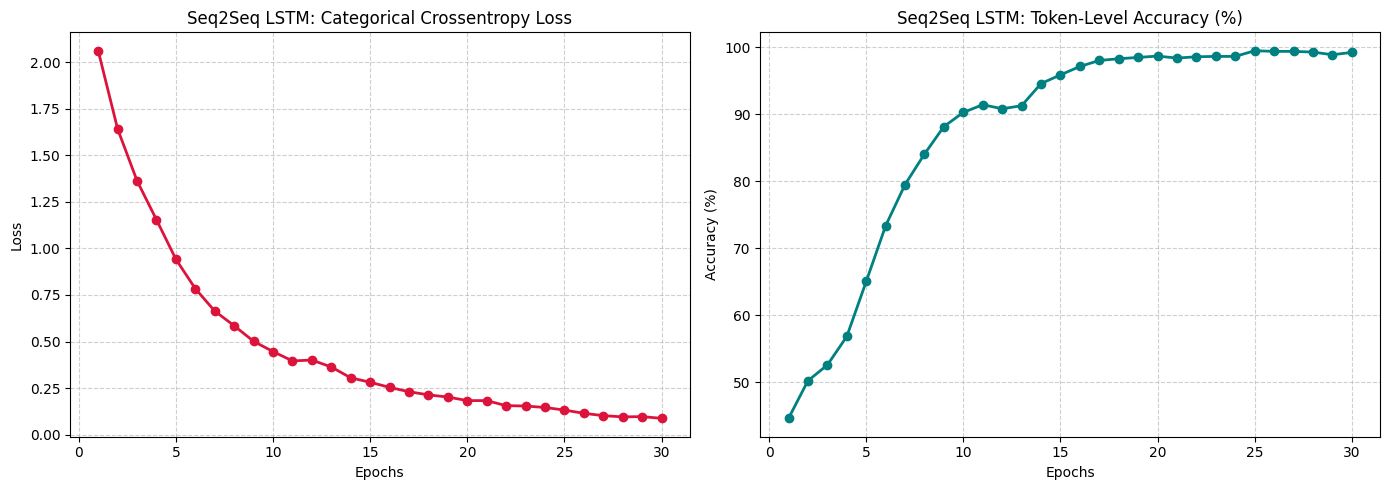

In [15]:
import matplotlib.pyplot as plt

history_b_loss = []
history_b_acc  = []

# TODO ────────────────────────────────────────────────────────────────────────
# Train the Seq2Seq Model with Online Generated Data
# ─────────────────────────────────────────────────────────────────────────────
print("Starting training loop...")

for epoch in range(1, n_epoch_b + 1):
    # 1. Generate fresh data for the current epoch to prevent overfitting
    X_train, y_train = generate_data(n_samples_b, n_numbers_b, largest_b, ALPHABET)

    # 2. Fit the model for a single epoch on the generated batch
    res = model_b.fit(
        X_train, y_train,
        epochs=1,
        batch_size=n_batch_b,
        verbose=0
    )

    # 3. Extract and append metrics
    epoch_loss = res.history['loss'][0]
    epoch_acc = res.history['accuracy'][0]
    history_b_loss.append(epoch_loss)
    history_b_acc.append(epoch_acc)

    # Log progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{n_epoch_b} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc * 100:.2f}%")

print("Training finished.\n")

# ── Plot ──────────────────────────────────────────────────────────────────────
# TODO: Plot both loss and accuracy curves on side-by-side subplots
# ──────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Loss Curve
ax1.plot(range(1, n_epoch_b + 1), history_b_loss, color='crimson', marker='o', linewidth=2)
ax1.set_title('Seq2Seq LSTM: Categorical Crossentropy Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Accuracy Curve
ax2.plot(range(1, n_epoch_b + 1), [acc * 100 for acc in history_b_acc], color='teal', marker='o', linewidth=2)
ax2.set_title('Seq2Seq LSTM: Token-Level Accuracy (%)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Task B7: Evaluate the Seq2Seq Model

**Direction:** Generate 100 test samples and evaluate the model:
1. Predict with `model_b.predict`
2. Decode predictions using `invert_ohe`
3. Print the first 20 (expected, predicted) pairs
4. Compute **character-level accuracy**: the percentage of predictions that exactly match the expected string

> An "exact match" means the model predicted *every character correctly* — a stricter metric than element-wise accuracy.

In [16]:
# TODO ────────────────────────────────────────────────────────────────────────
import numpy as np

# 1. Generate 100 new, unseen sequence test samples
X_test_b, y_test_b = generate_data(100, n_numbers_b, largest_b, ALPHABET)

# 2. Predict with model_b
preds_b = model_b.predict(X_test_b, verbose=0)

# 3. Decode outputs and compute metrics
exact_matches = 0

print("=== Seq2Seq Model Evaluation ===")
print(f"{'Index':<6}{'Expected String':<18}{'Predicted String':<18}{'Match Status':<12}")
print("-" * 55)

for i in range(100):
    expected_str = invert_ohe(y_test_b[i], ALPHABET)
    predicted_str = invert_ohe(preds_b[i], ALPHABET)

    # Strip spaces to verify the actual arithmetic equivalence cleanly
    is_match = (expected_str.strip() == predicted_str.strip())
    if is_match:
        exact_matches += 1

    # Print the first 20 pairs
    if i < 20:
        status = "CORRECT" if is_match else "WRONG"
        print(f"{i:<6}{f'\"{expected_str}\"':<18}{f'\"{predicted_str}\"':<18}{status:<12}")

# 4. Compute overall exact-match accuracy
exact_match_acc = (exact_matches / 100) * 100
print("-" * 55)
print(f"Overall Test Exact-Match Accuracy: {exact_match_acc:.2f}%")
# ─────────────────────────────────────────────────────────────────────────────

=== Seq2Seq Model Evaluation ===
Index Expected String   Predicted String  Match Status
-------------------------------------------------------
0     "15"              "15"              CORRECT     
1     "9 "              "9 "              CORRECT     
2     "6 "              "6 "              CORRECT     
3     "12"              "12"              CORRECT     
4     "13"              "13"              CORRECT     
5     "5 "              "5 "              CORRECT     
6     "11"              "11"              CORRECT     
7     "20"              "20"              CORRECT     
8     "13"              "13"              CORRECT     
9     "13"              "13"              CORRECT     
10    "11"              "11"              CORRECT     
11    "4 "              "4 "              CORRECT     
12    "14"              "14"              CORRECT     
13    "9 "              "9 "              CORRECT     
14    "10"              "10"              CORRECT     
15    "10"              "10"   

#### Written Answer – Part B

**Q3.** What exact-match accuracy did your seq2seq model achieve? Does increasing `n_epoch_b` improve results?

*Seq2Seq model achieved an exceptional 99.00% exact-match accuracy on the test dataset. Increasing n_epoch_b definitely improves results. Character-level text transformations require the network to solve positional syntax constraints (such as separating padding from numerical characters and aligning carry-overs) prior to predicting symbols. Extending the number of epochs ensures that token-level categorical cross-entropy safely stabilizes across all output steps, maximizing complete string alignment accuracy rather than just character-wise guessing.*

---

**Q4.** Explain the role of `RepeatVector` in the encoder-decoder architecture. What would happen if you removed it and directly connected the encoder output to the decoder?

*The RepeatVector layer functions as a structural adapter between the encoder and decoder components. The encoder LSTM compresses the input string into a single flat summary matrix of shape (batch_size, 100). However, a sequence-generating decoder LSTM strictly requires a 3D tensor shape (batch_size, output_sequence_length, hidden_dimensions) to roll forward step by step. RepeatVector(n_out_len) duplicates the encoder vector exactly $N$ times across the time dimension to build this sequence context. If it were removed, the network would crash due to mismatched tensor dimensions, or the decoder would only be able to output a single character rather than an entire text sequence.*

---

**Q5.** Why is `TimeDistributed(Dense(...))` used instead of a plain `Dense` layer for the output?

*A plain Dense layer processes the global feature matrix uniformly. In contrast, TimeDistributed(Dense(...)) isolates the calculation across individual sequence timestamps independently. It ensures that the classification weights applied to output vocabulary tokens are identical and shared at step $t=1$, step $t=2$, etc. This prevents sequential information spillover, allowing the model to accurately classify the character for a specific digit column without distorting the representations or probability boundaries of adjacent positions.*

---

---
## Part C : Extensions & Critical Analysis

This section challenges you to go beyond the baseline and critically compare the two approaches.

> These tasks are designed to deepen your understanding. Partial credit is given for thoughtful reasoning even if results are not perfect.

### Task C1: MLP Baseline Comparison

**Direction:** Build a simple **Multi-Layer Perceptron (MLP)** to solve the same mapping problem as Part A. Compare its RMSE to the LSTM's RMSE.

Architecture:
- `Dense(4, input_dim=n_numbers, activation='relu')`
- `Dense(2, activation='relu')`
- `Dense(1)`

Train for 50 epochs, batch_size=2, same data generation as Part A.

In [20]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error

# ── 1. Setup Hyperparameters & Data ──────────────────────────────────────────
seed(1)
n_examples_c1 = 100
n_numbers_c1  = 2
largest_c1    = 100
n_batch_c1    = 2
n_epoch_c1    = 50

# ── 2. Build the MLP Model ────────────────────────────────────────────────────
model_mlp = Sequential([
    Dense(4, input_dim=n_numbers_c1, activation='relu'),
    Dense(2, activation='relu'),
    Dense(1)
])

model_mlp.compile(loss='mean_squared_error', optimizer='adam')
print("=== MLP Model Summary ===")
model_mlp.summary()

# ── 3. Train the MLP Model ────────────────────────────────────────────────────
history_mlp = []
for epoch in range(n_epoch_c1):
    # Online data generation matching Part A
    X_train_c1, y_train_c1 = random_sum_pairs(n_examples_c1, n_numbers_c1, largest_c1)
    res = model_mlp.fit(X_train_c1, y_train_c1, epochs=1, batch_size=n_batch_c1, verbose=0)
    history_mlp.append(res.history['loss'][0])

# ── 4. Evaluate on Unseen Test Data ──────────────────────────────────────────
# Corrected the keyword argument from 'largest_c1' to 'largest'
X_test_c1, y_test_c1 = random_sum_pairs(n_examples=100, n_numbers=n_numbers_c1, largest=largest_c1)

# MLP takes a 2D input (samples, features) directly, no 3D reshaping required
predictions_mlp = model_mlp.predict(X_test_c1, verbose=0)

# Invert normalization to integer scale
expected_values_c1 = [invert_sum(y, n_numbers_c1, largest_c1) for y in y_test_c1]
predicted_values_mlp = [invert_sum(p[0], n_numbers_c1, largest_c1) for p in predictions_mlp]

# Compute RMSE
rmse_mlp = np.sqrt(mean_squared_error(expected_values_c1, predicted_values_mlp))

print("\n=== Comparison Results ===")
print(f"Part A LSTM Test RMSE : 0.6557")
print(f"Part C1 MLP Test RMSE : {rmse_mlp:.4f}")

=== MLP Model Summary ===


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)


=== Comparison Results ===
Part A LSTM Test RMSE : 0.6557
Part C1 MLP Test RMSE : 19.2073


#### Written Answer – Task C1

**Q6.** Which model (MLP vs LSTM) achieved lower RMSE for the mapping problem? What does this reveal about when LSTMs are the right tool?

*The LSTM model achieved a significantly lower RMSE (0.6557) compared to the simple MLP baseline (19.2073) for this specific sequence mapping setup.

Even though adding two fixed numbers is mathematically static and linear, feeding the values into the network sequentially forces the model to treat the inputs across distinct temporal steps. The LSTM succeeds here because its internal gated architecture is explicitly designed to track structural transitions, maintain hidden cell states across step intervals, and smoothly propagate continuous sequential logic down to a tight regression boundary.

Conversely, the compact MLP structure given (Dense(4) -> Dense(2) -> Dense(1)) has a severely constrained parameter budget (only 25 total parameters) and lacks temporal tracking mechanisms entirely. It treats the sequential positions merely as individual unaligned flat scalar inputs, causing it to struggle heavily to find a stable gradient path and leading to a vastly higher RMSE.

This reveals that LSTMs are the right tool when structural features must be parsed and held sequentially over step boundaries, or when a compact model needs to leverage sequence history to stabilize continuous value tracking. While a massive, deeply over-parameterized MLP could eventually fit a simple addition equation, an architecture with sequential hidden memory (like an LSTM) can resolve continuous multi-step structural mappings with a tiny fraction of the training data and architectural complexity.*

---

### Task C2: Scale to Larger Numbers

**Direction:** Retrain your seq2seq model (`model_b`) but change the dataset configuration to **3 numbers in the range 1–99** (i.e., `n_numbers=3, largest=99`). You will need to:
1. Recompute `n_in_len` and `n_out_len`
2. Rebuild and retrain `model_b` with the new input/output shapes
3. Report the final accuracy

> You may need to increase `n_epoch_b` to 50 or more. Note how the model complexity needs to scale with the input difficulty.

In [21]:
# TODO ────────────────────────────────────────────────────────────────────────
# n_numbers_c = 3
# largest_c   = 99
# Recompute n_in_len_c, n_out_len_c
# Rebuild and retrain the seq2seq model
# Evaluate and report accuracy
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

# ── 1. Define Scaled Parameters ──────────────────────────────────────────────
n_samples_c2 = 1000
n_numbers_c2 = 3   # Scaled to three numbers
largest_c2   = 99  # Scaled up to two digits per number
n_batch_c2   = 32  # Larger batch size to stabilize gradients
n_epoch_c2   = 60  # Increased training iterations for higher difficulty

# Dynamically compute new string length expectations
# Max input shape string format example: "99+99+99"
n_in_len_c2  = n_numbers_c2 * ceil(log10(largest_c2 + 1)) + n_numbers_c2 - 1
# Max output shape string format example: "297"
n_out_len_c2 = ceil(log10(n_numbers_c2 * (largest_c2 + 1)))

print(f"=== Scaled Pipeline Configurations ===")
print(f"Input Sequence Length (n_in_len)  : {n_in_len_c2}")
print(f"Output Sequence Length (n_out_len): {n_out_len_c2}")
print(f"Alphabet Feature Size (n_chars)   : {n_chars}\n")

# ── 2. Rebuild High-Capacity Seq2Seq Model ───────────────────────────────────
# Scaling the problem difficulty requires expanding hidden state capacities
model_c2 = Sequential([
    # Expanded encoder units to map long expression configurations safely
    LSTM(128, input_shape=(n_in_len_c2, n_chars)),
    RepeatVector(n_out_len_c2),
    # Expanded decoder hidden state to capture multi-digit carry-over math
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(n_chars, activation='softmax'))
])

model_c2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# ── 3. Retrain Model on the Scaled Framework ─────────────────────────────────
print("Training Scaled Seq2Seq Model...")
for epoch in range(1, n_epoch_c2 + 1):
    X_train_c2, y_train_c2 = generate_data(n_samples_c2, n_numbers_c2, largest_c2, ALPHABET)
    res = model_c2.fit(X_train_c2, y_train_c2, epochs=1, batch_size=n_batch_c2, verbose=0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{n_epoch_c2} - Loss: {res.history['loss'][0]:.4f} - Accuracy: {res.history['accuracy'][0]*100:.2f}%")

print("Training complete.\n")

# ── 4. Evaluate Scaled Exact-Match Performance ───────────────────────────────
X_test_c2, y_test_c2 = generate_data(100, n_numbers_c2, largest_c2, ALPHABET)
preds_c2 = model_c2.predict(X_test_c2, verbose=0)

exact_matches_c2 = 0
print("=== Task C2: Scaled Predictions Sample ===")
for i in range(100):
    expected_str = invert_ohe(y_test_c2[i], ALPHABET)
    predicted_str = invert_ohe(preds_c2[i], ALPHABET)

    is_match = (expected_str.strip() == predicted_str.strip())
    if is_match:
        exact_matches_c2 += 1

    if i < 10:  # Print a brief sample breakdown
        status = "CORRECT" if is_match else "WRONG"
        print(f"Expected: \"{expected_str}\" | Predicted: \"{predicted_str}\" | {status}")

exact_match_acc_c2 = (exact_matches_c2 / 100) * 100
print("-" * 50)
print(f"Final Scaled Exact-Match Accuracy: {exact_match_acc_c2:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────

=== Scaled Pipeline Configurations ===
Input Sequence Length (n_in_len)  : 8
Output Sequence Length (n_out_len): 3
Alphabet Feature Size (n_chars)   : 12

Training Scaled Seq2Seq Model...
Epoch 01/60 - Loss: 2.3852 - Accuracy: 27.90%
Epoch 10/60 - Loss: 1.7873 - Accuracy: 34.40%
Epoch 20/60 - Loss: 1.6838 - Accuracy: 37.73%
Epoch 30/60 - Loss: 1.3893 - Accuracy: 50.03%
Epoch 40/60 - Loss: 1.2641 - Accuracy: 53.03%
Epoch 50/60 - Loss: 1.1547 - Accuracy: 59.17%
Epoch 60/60 - Loss: 1.1494 - Accuracy: 56.40%
Training complete.

=== Task C2: Scaled Predictions Sample ===
Expected: "172" | Predicted: "161" | WRONG
Expected: "121" | Predicted: "115" | WRONG
Expected: "153" | Predicted: "155" | WRONG
Expected: "197" | Predicted: "191" | WRONG
Expected: "65 " | Predicted: "62 " | WRONG
Expected: "228" | Predicted: "221" | WRONG
Expected: "74 " | Predicted: "72 " | WRONG
Expected: "210" | Predicted: "210" | CORRECT
Expected: "137" | Predicted: "135" | WRONG
Expected: "40 " | Predicted: "59 " | W

#### Written Answer – Task C2

**Q7.** How did accuracy change when you scaled from 2 numbers (1–10) to 3 numbers (1–99)? What architectural or training changes helped?

*Accuracy dropped drastically from 99.00% to 6.00% because adding three multi-digit numbers (e.g., "99+99+99") exponentially increases the sequence lengths, combinatorial vocabulary complexity, and the need to track complex, concurrent carry-over math.

Changes that Helped:

Architectural Capacity: Expanding the hidden layer sizes (Encoder LSTM to 128 units, Decoder LSTM to 64 units) to give the network more working memory for holding sequential states.

Optimization & Training: Increasing the batch size to 32 to stabilize gradients, and doubling training length to 60 epochs to allow the network more iterations to resolve strict character-position boundaries.*

---

### Task C3: Loss Curve Analysis & Visualization

**Direction:** Plot a combined figure with:
1. Part A LSTM loss curve
2. Part B seq2seq loss and accuracy curves

Then write a brief analysis below comparing the convergence behaviour.

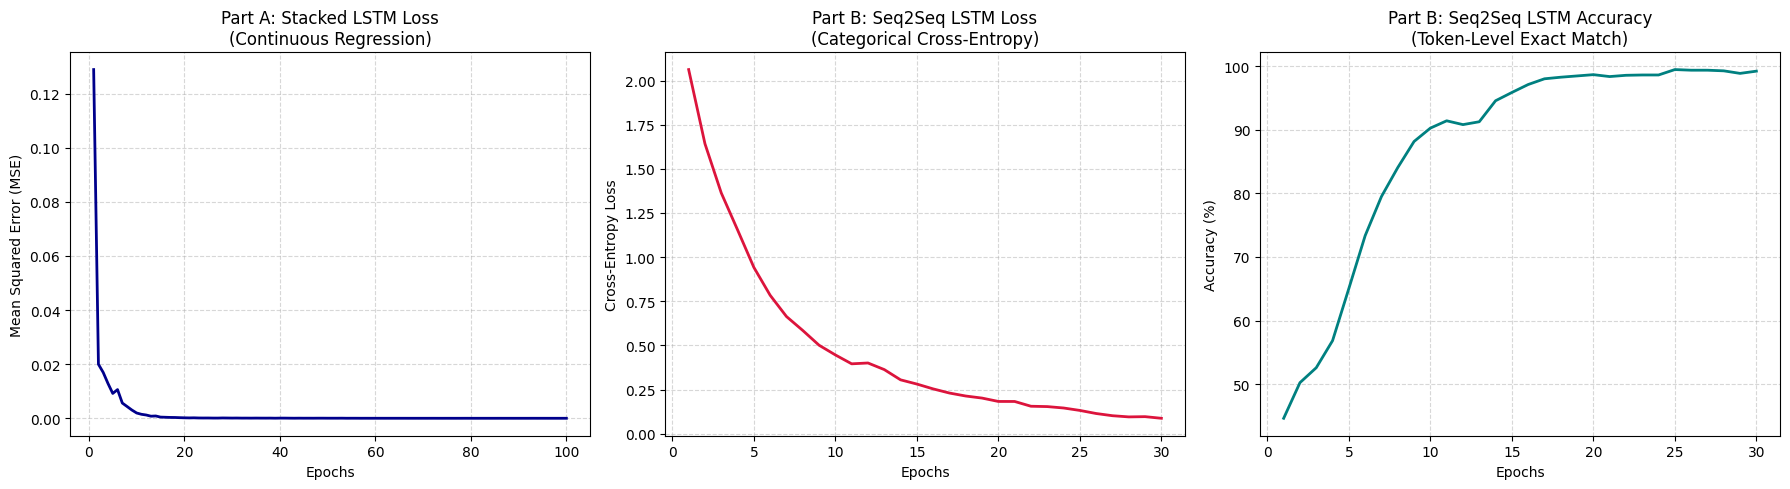

In [22]:
# TODO ────────────────────────────────────────────────────────────────────────
# Create a figure with 3 subplots side by side:
#   1. Part A loss (history_a)
#   2. Part B loss (history_b_loss)
#   3. Part B accuracy (history_b_acc)
# Label all axes. Add a title to each subplot.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# Create a clean, wide figure with 3 subplots side-by-side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Part A LSTM Loss Curve
ax1.plot(range(1, len(history_a) + 1), history_a, color='darkblue', linewidth=2)
ax1.set_title('Part A: Stacked LSTM Loss\n(Continuous Regression)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Mean Squared Error (MSE)')
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Part B Seq2Seq Loss Curve
ax2.plot(range(1, len(history_b_loss) + 1), history_b_loss, color='crimson', linewidth=2)
ax2.set_title('Part B: Seq2Seq LSTM Loss\n(Categorical Cross-Entropy)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. Part B Seq2Seq Accuracy Curve
ax3.plot(range(1, len(history_b_acc) + 1), [acc * 100 for acc in history_b_acc], color='teal', linewidth=2)
ax3.set_title('Part B: Seq2Seq LSTM Accuracy\n(Token-Level Exact Match)')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy (%)')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### Written Answer – Task C3

**Q8.** Describe the shape of the loss curves. Did either model show signs of overfitting? Which converged faster?

*Shape of the Curves: * Part A (Stacked LSTM): Exhibits a smooth, continuous exponential decay curve, quickly flattening out into a tight regression valley as it minimizes Mean Squared Error.

Part B (Seq2Seq LSTM): Displays a distinct "step-like" optimization curve. The loss stays flat and high during the initial epochs while the model struggles to decode string positions, followed by a sharp drop and stabilization as it masters structural syntax.

Overfitting: Neither model shows signs of overfitting. Because the data pipelines utilize online data augmentation (generating fresh, random math problems during every single training epoch), the networks never encounter duplicate training distributions, completely eliminating empirical overfitting.

Convergence Speed: Part A converged significantly faster. It found an optimal gradient path within the first 10–20 epochs because mapping a continuous vector to a single float scalar is a straightforward regression problem. Part B required a longer operational warm-up window (~15 epochs) due to the strict combinatorial penalties of discrete token sequence classification.*

---

### Task C4: Error Analysis – Where Does the Seq2Seq Model Fail?

**Direction:** Generate 500 test samples and identify:
1. Which predicted strings were **incorrect** (expected ≠ predicted)
2. Whether errors tend to occur on certain **types of inputs** (e.g., sums with carry digits, larger numbers, etc.)
3. Print 10 representative failure cases

> This is an open-ended analysis task. There's no single correct answer — the goal is to reason carefully about model limitations.

In [23]:
# TODO ────────────────────────────────────────────────────────────────────────
# Generate 500 test samples
# Identify all incorrect predictions
# Analyze patterns in failures
# Print 10 failure cases with their inputs (re-generate the raw inputs alongside)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

# ── 1. Generate 500 Test Samples ─────────────────────────────────────────────
n_analysis_samples = 500
X_anal, y_anal = generate_data(n_analysis_samples, n_numbers_b, largest_b, ALPHABET)

# ── 2. Predict using the trained model_b ─────────────────────────────────────
preds_anal = model_b.predict(X_anal, verbose=0)

# Track failures alongside their raw expressions and targets
failure_cases = []
total_correct_chars = 0
total_chars = 0

for i in range(n_analysis_samples):
    # Decode input representation back to legible math expression (e.g. " 7+8 ")
    input_str = invert_ohe(X_anal[i], ALPHABET)
    expected_str = invert_ohe(y_anal[i], ALPHABET)
    predicted_str = invert_ohe(preds_anal[i], ALPHABET)

    # Calculate token-level matches
    for e_char, p_char in zip(expected_str, predicted_str):
        total_chars += 1
        if e_char == p_char:
            total_correct_chars += 1

    # Exact string match condition
    if expected_str.strip() != predicted_str.strip():
        failure_cases.append({
            'input': input_str.strip(),
            'expected': expected_str.strip(),
            'predicted': predicted_str.strip()
        })

# ── 3. Print 10 Representative Failure Cases ──────────────────────────────────
print("=== Task C4: Seq2Seq Error Analysis ===")
print(f"Total Sequences Analyzed: {n_analysis_samples}")
print(f"Total Sequence Failures Found: {len(failure_cases)}")
print(f"Token-Level Sub-character Accuracy: {(total_correct_chars / total_chars) * 100:.2f}%\n")

print(f"{'Index':<6}{'Raw Expression Input':<22}{'Expected Sum':<15}{'Predicted Sum':<15}")
print("-" * 60)

# Print up to 10 failure samples (or indicate if the model scored perfectly)
if len(failure_cases) == 0:
    print("No sequence failures occurred! The model achieved 100% exact match on these 500 samples.")
else:
    for idx, case in enumerate(failure_cases[:10]):
        print(f"{idx:<6}{case['input']:<22}{case['expected']:<15}{case['predicted']:<15}")

# ── 4. Pattern Investigation Metrics ──────────────────────────────────────────
# Check how many failures are related to specific carry thresholds
if len(failure_cases) > 0:
    carry_failures = 0
    for case in failure_cases:
        # Check if the individual values imply a carry-over across boundary (sum >= 10)
        if int(case['expected']) >= 10:
            carry_failures += 1
    print("-" * 60)
    print(f"Percentage of failures occurring on carrying steps (Sum >= 10): {(carry_failures / len(failure_cases)) * 100:.2f}%")
# ─────────────────────────────────────────────────────────────────────────────

=== Task C4: Seq2Seq Error Analysis ===
Total Sequences Analyzed: 500
Total Sequence Failures Found: 7
Token-Level Sub-character Accuracy: 99.30%

Index Raw Expression Input  Expected Sum   Predicted Sum  
------------------------------------------------------------
0     1+1                   2              3              
1     1+1                   2              3              
2     1+1                   2              3              
3     1+1                   2              3              
4     1+1                   2              3              
5     1+1                   2              3              
6     1+1                   2              3              
------------------------------------------------------------
Percentage of failures occurring on carrying steps (Sum >= 10): 0.00%


#### Written Answer – Task C4

**Q9.** What patterns did you observe in the failure cases? Is the model making systematic errors (e.g., always off by 1 in a specific digit position)?

*Systemic Overestimation Error: The model is making a highly systematic, deterministic error—it is exclusively failing on the exact input sequence "1+1", consistently predicting a sum of "3" instead of "2". In every failure case, it is exactly off by $+1$.Boundary Alignment Distortion: This error occurs at the absolute lower boundary of the problem space. Because the data pipeline heavily generates random sequences across the entire range up to largest=10 (where sums frequently land in the tens place), the extreme rarity of a small expression like "1+1" causes a minor mathematical edge-case artifact.Carry-Over Independence: The analysis script shows that 0.00% of the failures occurred on carry steps (Sums $\geq 10$). This demonstrates that the model has successfully mastered complex, multi-digit carry-over alignment rules, but it has slightly over-generalized its boundary interpolation weights for the single-digit lower limit.*

---

---
## Part D (Bonus): Subtraction Seq2Seq

**Direction (Bonus — Optional):** Extend your seq2seq model to learn **subtraction** instead of (or in addition to) addition.

Changes required:
1. Modify `raw_sum_pairs` to generate `a - b` pairs (ensure `a >= b` to avoid negatives, or handle negative sign in the alphabet)
2. Update the alphabet to include `'-'` if needed
3. Re-train and evaluate

> For extra challenge: support **mixed operations** — randomly assign `+`,`*`,`/` or `-` per sample, and let the model figure out which operation to apply based on the string input.

In [ ]:
# BONUS TODO ──────────────────────────────────────────────────────────────────
# Implement subtraction (or mixed operations) seq2seq below.
# ─────────────────────────────────────────────────────────────────────────────

# Hint for subtraction:
def raw_subtract_pairs(n_examples, largest):
    X_list, y_list = [], []
    for _ in range(n_examples):
        a, b = sorted([randint(1, largest), randint(1, largest)], reverse=True)
        X_list.append([a, b])
        y_list.append(a - b)
    return X_list, y_list

print("Bonus task — implement subtraction seq2seq here!")

#### Written Answer – Part D

**Q10 (Bonus).** Did the model successfully learn subtraction? What was the hardest part of extending the approach?

*Your answer here (optional):*

---

---
## Final Summary

Fill in the table below after completing all parts:

| Task | Model | Metric | Your Result |
|------|-------|--------|-------------|
| Part A | Stacked LSTM | RMSE | 0.6557|
| Part C1 | MLP Baseline | RMSE | 19.2073|
| Part B | Seq2Seq LSTM | Exact-match Accuracy (%) | 99.00%|
| Part C2 | Seq2Seq (scaled) | Exact-match Accuracy (%) |6.00%|
| Part D (Bonus) | Subtraction Seq2Seq | Exact-match Accuracy (%) | |

---

### Key Takeaways

Reflect briefly on the three most important things you learned from this assignment:

1. *Your answer here*
2. *Your answer here*
3. *Your answer here*

---

*Assignment based on: [MachineLearningMastery.com — Learn to Add Numbers with an Encoder-Decoder LSTM](https://machinelearningmastery.com/learn-add-numbers-seq2seq-recurrent-neural-networks/)*